In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df= pd.read_csv("loan_data.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1


In [3]:
df.tail()

,Age,Income,LoanAmount,CreditScore,Approved
44995,27,47971,15000,645,1
44996,37,65800,9000,621,1
44997,33,56942,2771,668,1
44998,29,33164,12000,604,1
44999,24,51609,6665,628,1


In [6]:
df.isna().sum()

Age            0
Income         0
LoanAmount     0
CreditScore    0
Approved       0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Age          45000 non-null  int64
 1   Income       45000 non-null  int64
 2   LoanAmount   45000 non-null  int64
 3   CreditScore  45000 non-null  int64
 4   Approved     45000 non-null  int64
dtypes: int64(5)
memory usage: 1.7 MB


In [8]:
df.describe()

,Age,Income,LoanAmount,CreditScore,Approved
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,9583.157556,632.608756,0.222222
std,6.045108,8.042250e+04,6314.886691,50.435865,0.415744
min,20.000000,8.000000e+03,500.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,5000.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,8000.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,12237.250000,670.000000,0.000000
max,144.000000,7.200766e+06,35000.000000,850.000000,1.000000


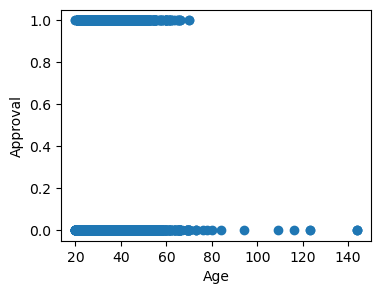

In [16]:
plt.figure(figsize=(4,3))
x= df["Age"]
y= df["Approved"]
plt.scatter(x,y)
plt.xlabel("Age")
plt.ylabel("Approval")
plt.show()

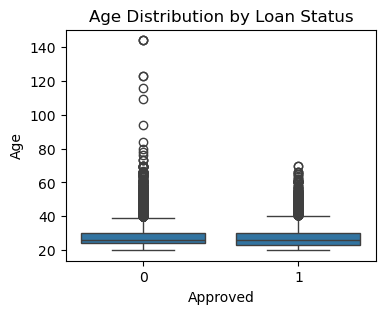

In [18]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Approved', y='Age', data=df)
plt.title('Age Distribution by Loan Status')
plt.show()

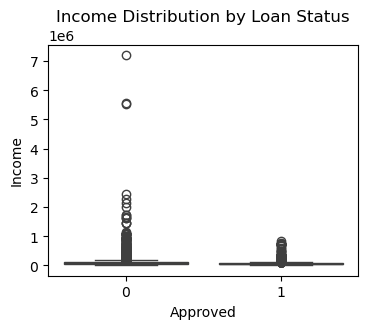

In [21]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Approved', y='Income', data=df)
plt.title('Income Distribution by Loan Status')
plt.show()

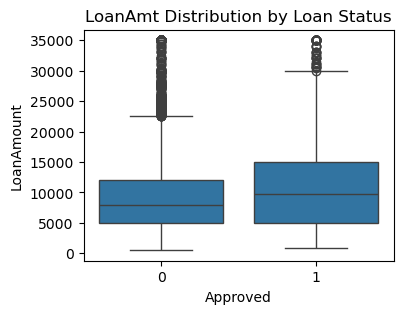

In [22]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Approved', y='LoanAmount', data=df)
plt.title('LoanAmt Distribution by Loan Status')
plt.show()

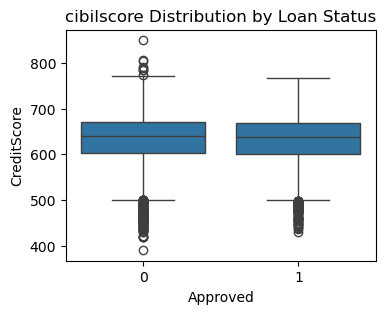

In [23]:
plt.figure(figsize=(4,3))
sns.boxplot(x='Approved', y='CreditScore', data=df)
plt.title('cibilscore Distribution by Loan Status')
plt.show()

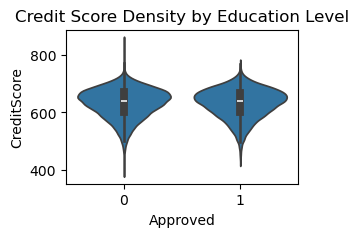

In [24]:
plt.figure(figsize=(3,2))
sns.violinplot(x='Approved', y='CreditScore', data=df)
plt.title('Credit Score Density by Education Level')
plt.show()

In [25]:
df

,Age,Income,LoanAmount,CreditScore,Approved
0,22,71948,35000,561,1
1,21,12282,1000,504,0
2,25,12438,5500,635,1
3,23,79753,35000,675,1
4,24,66135,35000,586,1
...,...,...,...,...,...
44995,27,47971,15000,645,1
44996,37,65800,9000,621,1
44997,33,56942,2771,668,1
44998,29,33164,12000,604,1


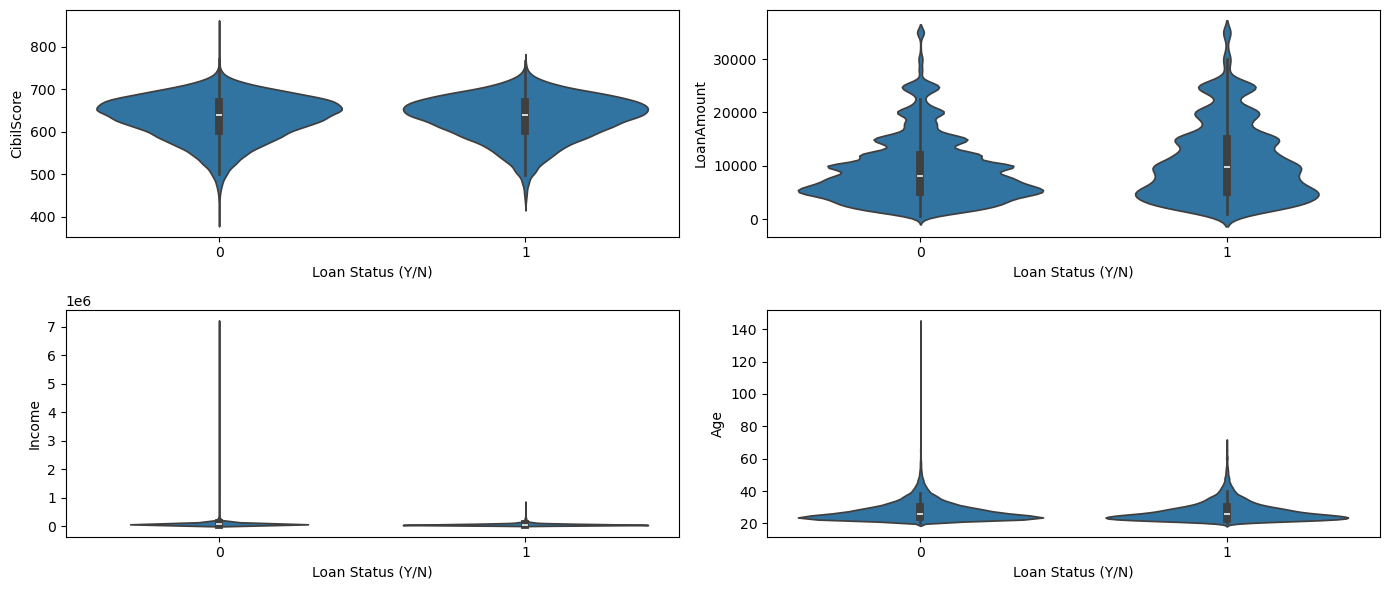

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 6))

sns.violinplot(x='Approved', y='CreditScore', data=df, ax=axes[0][0])
axes[0][0].set_xlabel('Loan Status (Y/N)')
axes[0][0].set_ylabel('CibilScore')

sns.violinplot(x='Approved', y='LoanAmount', data=df, ax=axes[0][1])
axes[0][1].set_xlabel('Loan Status (Y/N)')
axes[0][1].set_ylabel('LoanAmount') 

sns.violinplot(x='Approved', y='Income', data=df, ax=axes[1][0])
axes[1][0].set_xlabel('Loan Status (Y/N)')
axes[1][0].set_ylabel('Income') 

sns.violinplot(x='Approved', y='Age', data=df, ax=axes[1][1])
axes[1][1].set_xlabel('Loan Status (Y/N)')
axes[1][1].set_ylabel('Age')
plt.tight_layout()
plt.show()

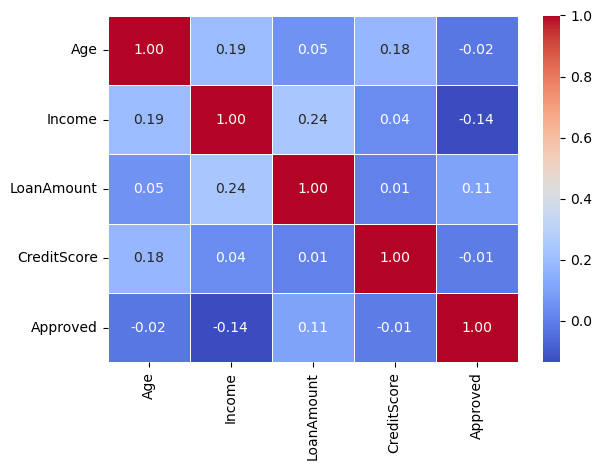

In [30]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidth=0.5)
plt.tight_layout()
plt.show()

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

In [36]:
X= df.drop(columns=["Approved"])
Y= df["Approved"]

In [39]:
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
model= LogisticRegression(random_state=42)
scores= cross_val_score(model, X, Y, cv=5)
print("Avg Accuracy= ",scores.mean())

Avg Accuracy=  0.7904222222222221


In [42]:
model= KNeighborsClassifier(n_neighbors=5)
scores= cross_val_score(model, X, Y, cv=5)
print("Avg Accuracy= ",scores.mean())

Avg Accuracy=  0.8315333333333333


In [48]:
model= DecisionTreeClassifier(max_depth=5, random_state=42)
scores= cross_val_score(model, X, Y, cv=5)
print("Avg Accuracy= ",scores.mean())

Avg Accuracy=  0.8354444444444444


In [49]:
from sklearn.model_selection import train_test_split

In [63]:
X_train,X_test,Y_train,Y_test= train_test_split(X,Y,test_size=0.3,random_state=42,stratify=Y)

In [64]:
model.fit(X_train,Y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [65]:
Y_pred= model.predict(X_test)

In [66]:
from sklearn.metrics import accuracy_score

In [67]:
print("Accuracy of the model: ",accuracy_score(Y_test,Y_pred))

Accuracy of the model:  0.8367407407407408
